In [1]:
import pandas as pd

# Ruta del archivo
ruta = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_completo.xlsx"

# ======================================================
# 1. Leer el archivo Excel
# ======================================================
df = pd.read_excel(ruta)

# ======================================================
# 2. Mostrar primeras filas y columnas
# ======================================================
print("\n=== Primeras filas del archivo ===")
print(df.head())

print("\n=== Columnas disponibles ===")
print(df.columns.tolist())

# ======================================================
# 3. Estadísticas básicas de todas las variables numéricas
# ======================================================
print("\n=== Estadísticas descriptivas ===")
print(df.describe(include='all'))

# ======================================================
# 4. Conteo de valores faltantes
# ======================================================
print("\n=== Valores faltantes por columna ===")
print(df.isna().sum())

# ======================================================
# 5. Si quieres estadísticas SOLO para algunas variables:
# ======================================================
variables_interes = [
    "planting", "vegetative", "harvest", "endofseaso", 
    "duracion_vegetativa", "duracion_hasta_cosecha", 
    "duracion_total", "outofseaso"
]

# Filtrar variables que realmente existan en el dataframe
variables_existentes = [v for v in variables_interes if v in df.columns]

print("\n=== Estadísticas para variables fenológicas ===")
print(df[variables_existentes].describe())



=== Primeras filas del archivo ===
  country region cultivo temporada       lat        lon  planting  vegetative  \
0  Guinea  South   maize         2  10.53007 -10.913203         0           0   
1  Guinea  South   wheat    spring  10.53007 -10.913203         0           0   
2  Guinea  South    rice         1  10.53007 -10.913203       121         244   
3  Guinea  South   wheat    winter  10.53007 -10.913203         0           0   
4  Guinea  South   maize         1  10.53007 -10.913203       121         182   

   harvest  endofseaso  duracion_vegetativa  duracion_hasta_cosecha  \
0        0           0                    0                       0   
1        0           0                    0                       0   
2      274           1                  123                     153   
3        0           0                    0                       0   
4      274         350                   61                     153   

   duracion_total  outofseaso  minimalpro  
0     

In [2]:
import pandas as pd
import numpy as np

# ======================================================
# 1. Cargar archivo
# ======================================================
ruta = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_completo.xlsx"
df = pd.read_excel(ruta)

# ======================================================
# 2. Filtrar temporadas válidas: cultivos que realmente existen
# ======================================================
df_valid = df[(df["minimalpro"] == 0) & (df["planting"] > 0)].copy()

# ======================================================
# 3. Crear banda latitudinal de 10° SEPARANDO HEMISFERIOS
# ======================================================
def banda_lat(row):
    lat = row["lat"]
    if lat >= 0:
        return f"N{int((lat // 10) * 10)}"   # N0, N10, N20, etc.
    else:
        return f"S{int((abs(lat) // 10) * 10)}"  # S0, S10, S20, etc.

df_valid["lat_band"] = df_valid.apply(banda_lat, axis=1)

# ======================================================
# 4. Calcular duraciones reales
# ======================================================
df_valid["dur_veg"] = df_valid["vegetative"] - df_valid["planting"]
df_valid["dur_rep"] = df_valid["harvest"] - df_valid["vegetative"]
df_valid["dur_total"] = df_valid["harvest"] - df_valid["planting"]

# Limpiar valores imposibles
df_valid = df_valid[(df_valid["dur_total"] > 0) & (df_valid["dur_total"] < 365)]

# ======================================================
# 5. Crear archivo detallado por país + cultivo + banda latitudinal
#    NOTA: aquí NO agrupamos — dejamos cada país y cultivo con su banda
# ======================================================

df_lat_pais = df_valid[[
    "country", "region", "cultivo", "lat", "lon",
    "lat_band", "planting", "vegetative", "harvest",
    "dur_veg", "dur_rep", "dur_total"
]].copy()

# Orden para que el archivo quede limpio
df_lat_pais = df_lat_pais.sort_values(by=["cultivo", "lat_band", "country"])

# ======================================================
# 6. Guardar archivo simplificado por latitud
# ======================================================
output = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx"
df_lat_pais.to_excel(output, index=False)

print("✔ Archivo creado en:", output)
print(df_lat_pais.head())


✔ Archivo creado en: C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx
       country     region cultivo       lat        lon lat_band  planting  \
1030     Benin    Central   maize  9.297628   2.413478       N0       213   
1032     Benin    Central   maize  9.297628   2.413478       N0        60   
1048     Benin      South   maize  7.054511   2.189423       N0        75   
1049     Benin      South   maize  7.054511   2.189423       N0       213   
154   Cameroon  Southwest   maize  5.272776  10.006422       N0        75   

      vegetative  harvest  dur_veg  dur_rep  dur_total  
1030         274      335       61       61        122  
1032         121      213       61       92        153  
1048         152      197       77       45        122  
1049         274      335       61       61        122  
154          121      228       46      107        153  


In [3]:
import pandas as pd

# Ruta de tu archivo
file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx"

# Cargar el Excel
df = pd.read_excel(file)

print("\n=======================")
print("    INFO DEL DATASET   ")
print("=======================\n")
print(df.info())

print("\n=======================")
print("  PRIMERAS 10 FILAS   ")
print("=======================\n")
print(df.head(10))

print("\n=======================")
print("  COLUMNAS Y TIPOS    ")
print("=======================\n")
for col in df.columns:
    print(f"{col} → {df[col].dtype}")

print("\n=======================")
print(" VALORES ÚNICOS CLAVES")
print("=======================\n")
for col in ["Pais", "Cultivo", "Latitud_Banda", "Etapa"]:
    if col in df.columns:
        print(f"\n>>> {col}:\n", df[col].unique()[:20])



    INFO DEL DATASET   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     415 non-null    object 
 1   region      415 non-null    object 
 2   cultivo     415 non-null    object 
 3   lat         415 non-null    float64
 4   lon         415 non-null    float64
 5   lat_band    415 non-null    object 
 6   planting    415 non-null    int64  
 7   vegetative  415 non-null    int64  
 8   harvest     415 non-null    int64  
 9   dur_veg     415 non-null    int64  
 10  dur_rep     415 non-null    int64  
 11  dur_total   415 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 39.0+ KB
None

  PRIMERAS 10 FILAS   

                    country      region cultivo       lat        lon lat_band  \
0                     Benin     Central   maize  9.297628   2.413478       N0   
1                     Benin     Central 

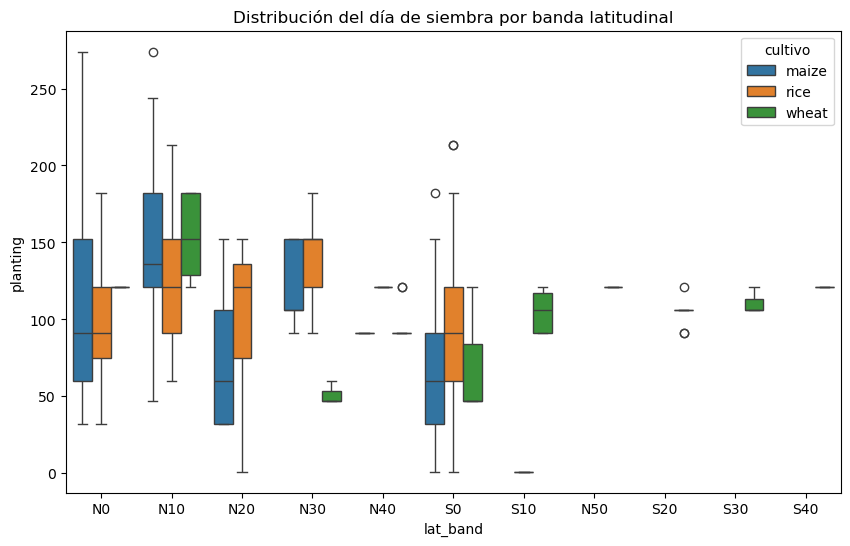

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="lat_band", y="planting", hue="cultivo")
plt.title("Distribución del día de siembra por banda latitudinal")
plt.show()


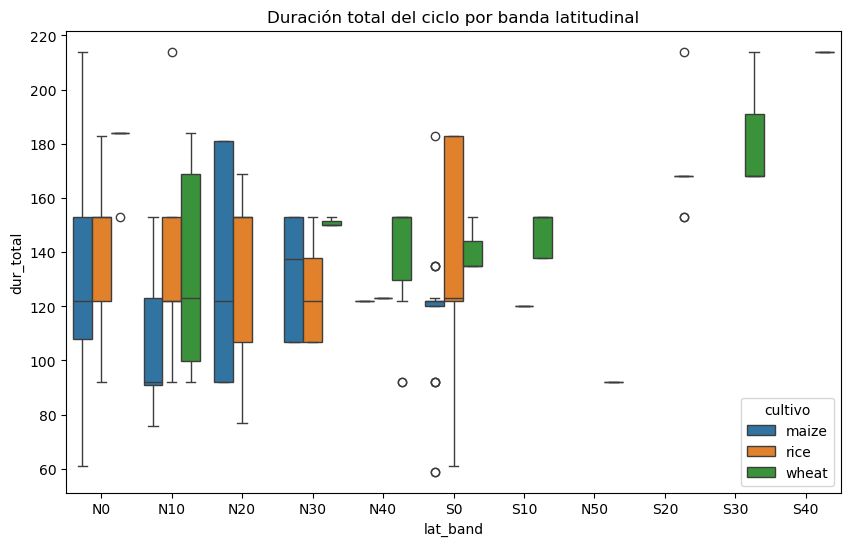

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="lat_band", y="dur_total", hue="cultivo")
plt.title("Duración total del ciclo por banda latitudinal")
plt.show()


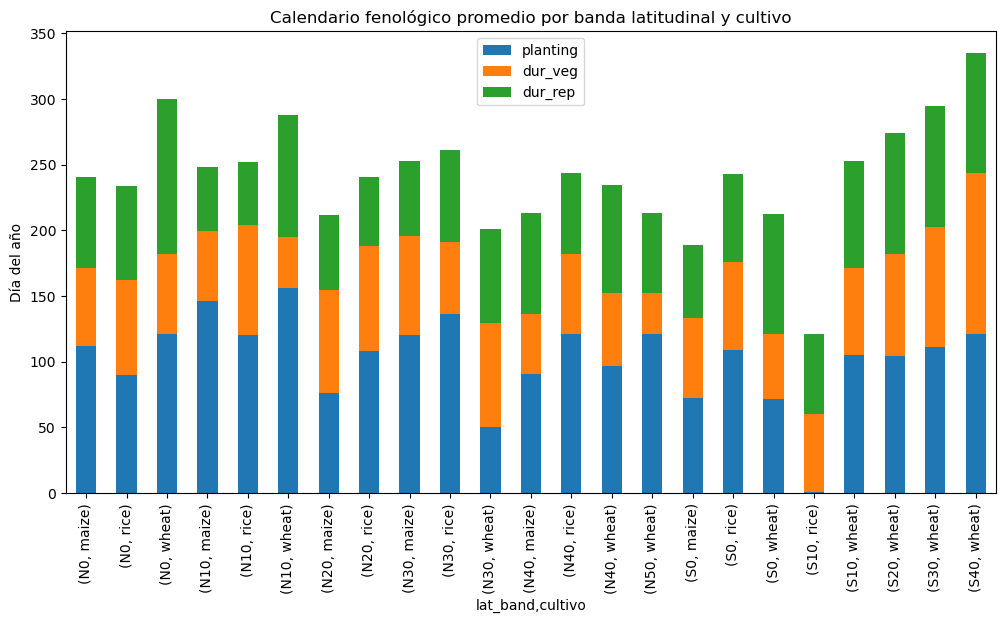

In [7]:
import matplotlib.pyplot as plt

# Agrupar correctamente
df_plot = df.groupby(["lat_band","cultivo"])[["planting","vegetative","harvest"]].mean().reset_index()

# Crear duración de fases
df_plot["dur_veg"] = df_plot["vegetative"] - df_plot["planting"]
df_plot["dur_rep"] = df_plot["harvest"] - df_plot["vegetative"]

# Preparar índices
df_plot = df_plot.set_index(["lat_band","cultivo"])[["planting","dur_veg","dur_rep"]]

# Graficar Gantt compacto
df_plot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Calendario fenológico promedio por banda latitudinal y cultivo")
plt.ylabel("Día del año")
plt.show()


In [8]:
# ================================================
# SCRIPT 1 — CREAR RESUMEN POR BANDA Y CULTIVO
# ================================================

import pandas as pd

# 1. Cargar datos
file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx"
df = pd.read_excel(file)

# 2. Columnas numéricas relevantes
num_cols = ["planting", "vegetative", "harvest", "dur_veg", "dur_rep", "dur_total"]

# Asegurar que son numéricas
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Crear resumen por lat_band y cultivo
df_summary = (
    df.groupby(["lat_band", "cultivo"])[num_cols]
    .mean()
    .reset_index()
)

# 4. Convertir bandas tipo "N0" → latitud central (5, 15, -5, etc.)
def band_to_lat_value(band):
    sign = 1 if band[0] == "N" else -1
    degrees = int(band[1:])
    return sign * (degrees + 5)

df_summary["lat_center"] = df_summary["lat_band"].apply(band_to_lat_value)

# 5. Ordenar tabla final
df_summary = df_summary.sort_values(["cultivo", "lat_center"]).reset_index(drop=True)

print("Resumen final listo para usar:")
print(df_summary.head(20))


Resumen final listo para usar:
   lat_band cultivo    planting  vegetative     harvest     dur_veg  \
0        S0   maize   72.714286  133.190476  188.857143   60.476190   
1        N0   maize  111.625000  171.250000  240.444444   59.625000   
2       N10   maize  146.433333  199.566667  248.100000   53.133333   
3       N20   maize   76.130435  154.391304  211.695652   78.260870   
4       N30   maize  120.083333  196.000000  252.583333   75.916667   
5       N40   maize   91.000000  136.000000  213.000000   45.000000   
6       S10    rice    1.000000   60.000000  121.000000   59.000000   
7        S0    rice  108.764706  175.941176  242.588235   67.176471   
8        N0    rice   90.181818  162.121212  233.848485   71.939394   
9       N10    rice  120.447368  204.236842  252.421053   83.789474   
10      N20    rice  108.357143  188.023810  240.357143   79.666667   
11      N30    rice  136.578947  191.052632  261.315789   54.473684   
12      N40    rice  121.000000  182.000000  2

In [9]:
# ================================================
# SCRIPT 2 — FUNCIÓN DE INTERPOLACIÓN FENOLÓGICA
# ================================================

import numpy as np
import pandas as pd

def fenologia_por_latitud(latitud, cultivo):
    """
    Devuelve fechas fenológicas estimadas para una latitud real (ej. 9°, 16°, -12°)
    basada en interpolación lineal entre bandas latitudinales.
    """
    # Filtrar el cultivo deseado
    d = df_summary[df_summary["cultivo"] == cultivo].sort_values("lat_center")

    # Asegurar que existen bandas para ese cultivo
    if len(d) < 2:
        raise ValueError(f"No hay suficientes bandas para interpolar el cultivo '{cultivo}'")

    # 1. Si la latitud está fuera del rango → tomar extremo más cercano
    if latitud <= d["lat_center"].min():
        return d.iloc[0][["planting","vegetative","harvest","dur_veg","dur_rep","dur_total"]]

    if latitud >= d["lat_center"].max():
        return d.iloc[-1][["planting","vegetative","harvest","dur_veg","dur_rep","dur_total"]]

    # 2. Encontrar las dos bandas adyacentes
    idx = np.searchsorted(d["lat_center"], latitud)
    low = d.iloc[idx - 1]
    high = d.iloc[idx]

    # 3. Fracción para interpolar entre bandas
    frac = (latitud - low["lat_center"]) / (high["lat_center"] - low["lat_center"])

    cols = ["planting","vegetative","harvest","dur_veg","dur_rep","dur_total"]

    # 4. Interpolación lineal
    interpolated = low[cols] + frac * (high[cols] - low[cols])

    return interpolated.round().astype(int)


In [10]:
print(fenologia_por_latitud(9, "maize"))
print(fenologia_por_latitud(16, "maize"))
print(fenologia_por_latitud(-12, "wheat"))


planting      125
vegetative    182
harvest       243
dur_veg        57
dur_rep        60
dur_total     117
dtype: int64
planting      139
vegetative    195
harvest       244
dur_veg        55
dur_rep        49
dur_total     105
dtype: int64
planting       94
vegetative    156
harvest       240
dur_veg        61
dur_rep        84
dur_total     145
dtype: int64


C:\Users\paola\AppData\Local\Temp\ipykernel_30512\2409631162.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_valid.groupby(["lat_band", "cultivo"])[["planting", "dur_veg", "dur_rep"]].mean().reset_index()


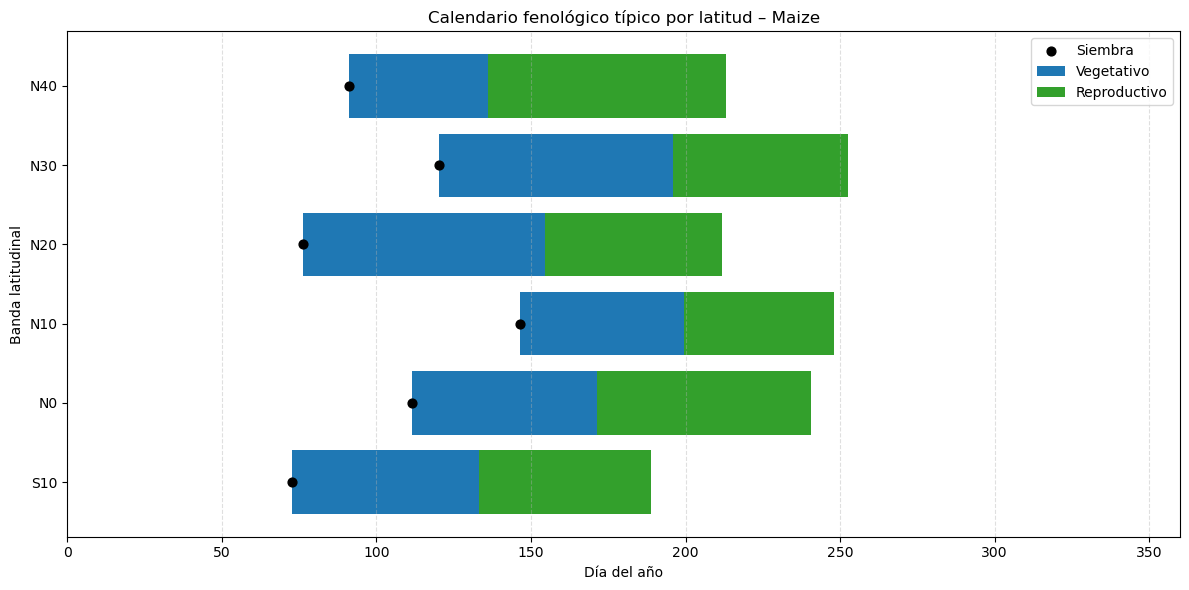

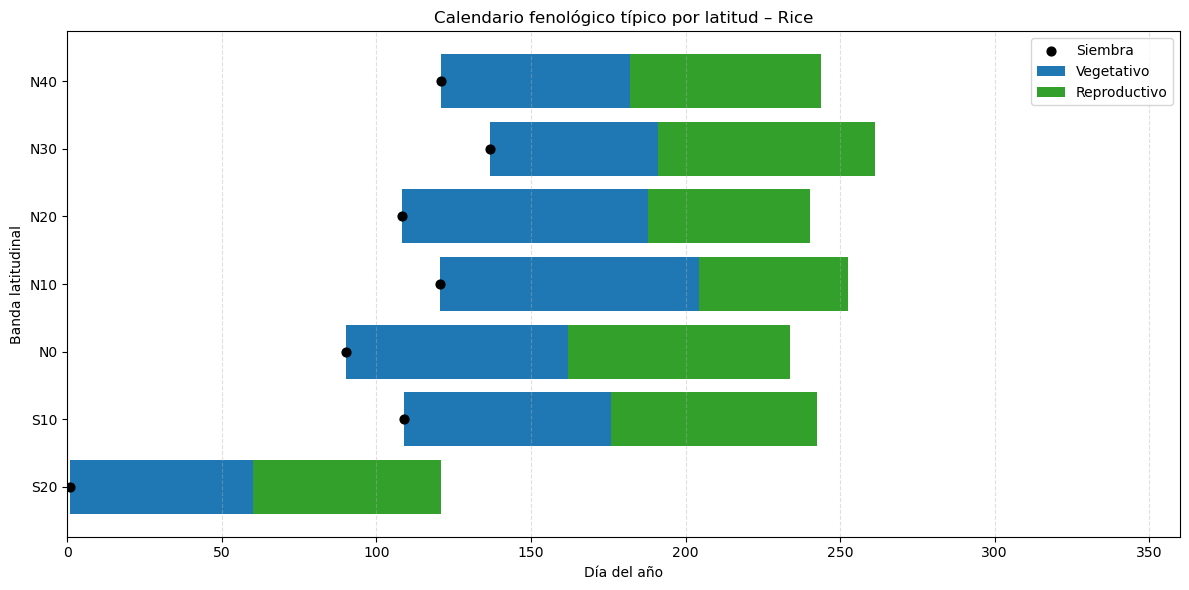

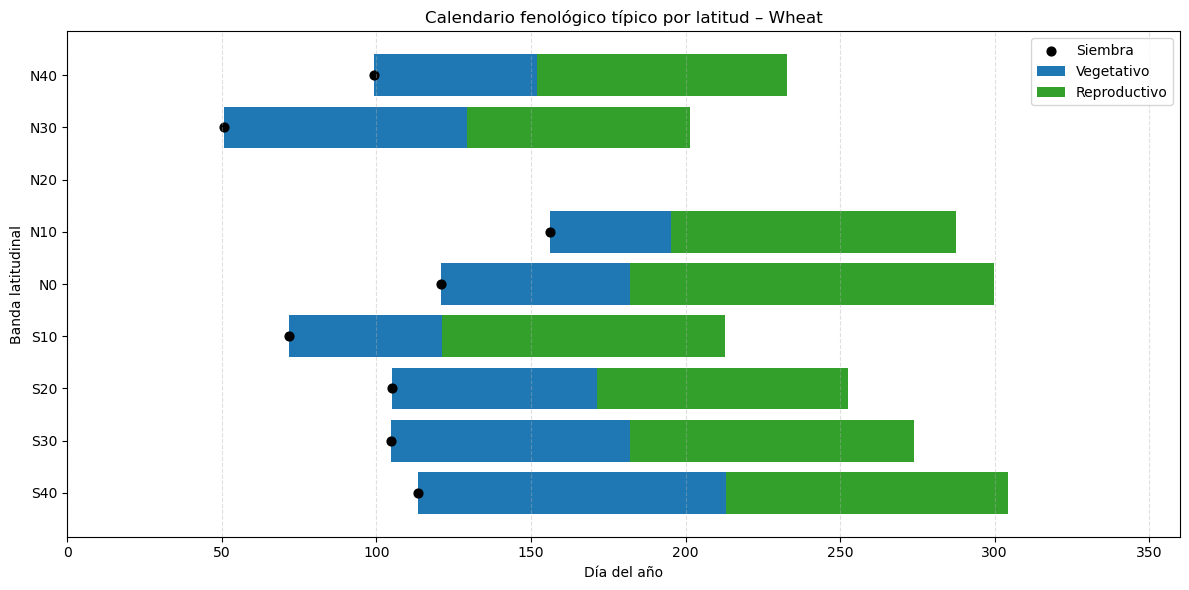

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. Cargar datos
# ============================
file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx"
df = pd.read_excel(file)

# ============================
# 2. Filtrar temporadas válidas
# ============================
df_valid = df[(df["planting"] > 0) & (df["harvest"] > 0)]

# ============================
# 3. Crear banda latitudinal
# ============================
def asignar_banda(lat):
    if lat < -30: return "S40"
    elif lat < -20: return "S30"
    elif lat < -10: return "S20"
    elif lat < 0: return "S10"
    elif lat < 10: return "N0"
    elif lat < 20: return "N10"
    elif lat < 30: return "N20"
    elif lat < 40: return "N30"
    else: return "N40"

df_valid["lat_band"] = df_valid["lat"].apply(asignar_banda)

# Orden correcto sur → norte
orden_lat = ["S40", "S30", "S20", "S10", "N0", "N10", "N20", "N30", "N40"]
df_valid["lat_band"] = pd.Categorical(df_valid["lat_band"], categories=orden_lat, ordered=True)

# ============================
# 4. Promedios correctos por banda y cultivo
# ============================
df_mean = df_valid.groupby(["lat_band", "cultivo"])[["planting", "dur_veg", "dur_rep"]].mean().reset_index()

# ============================
# 5. Graficar timeline fenológico horizontal
# ============================
cultivos = df_mean["cultivo"].unique()

for crop in cultivos:
    sub = df_mean[df_mean["cultivo"] == crop]

    plt.figure(figsize=(12, 6))

    # Barras de vegetativo
    plt.barh(sub["lat_band"],
             sub["dur_veg"],
             left=sub["planting"],
             color="#1f78b4",
             label="Vegetativo")

    # Barras de reproductivo
    plt.barh(sub["lat_band"],
             sub["dur_rep"],
             left=sub["planting"] + sub["dur_veg"],
             color="#33a02c",
             label="Reproductivo")

    # Punto de siembra
    plt.scatter(sub["planting"], sub["lat_band"],
                color="black", s=40, label="Siembra")

    plt.title(f"Calendario fenológico típico por latitud – {crop.capitalize()}")
    plt.xlabel("Día del año")
    plt.ylabel("Banda latitudinal")
    plt.xlim(0, 360)
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_por_Pais_Latitud.xlsx"
df = pd.read_excel(file)

# Filtrar temporadas válidas
df_valid = df[(df["planting"] > 0) & (df["harvest"] > 0)]

# Normalizar columna temporada
def limpiar_temporada(x):
    if isinstance(x, str):
        if "winter" in x.lower(): return 1
        if "spring" in x.lower(): return 2
    return int(x)

df_valid["temporada_clean"] = df["temporada"].apply(limpiar_temporada)

# Crear lat_band
def asignar_banda(lat):
    if lat < -30: return "S40"
    elif lat < -20: return "S30"
    elif lat < -10: return "S20"
    elif lat < 0: return "S10"
    elif lat < 10: return "N0"
    elif lat < 20: return "N10"
    elif lat < 30: return "N20"
    elif lat < 40: return "N30"
    else: return "N40"

df_valid["lat_band"] = df_valid["lat"].apply(asignar_banda)
orden_lat = ["S40", "S30", "S20", "S10", "N0", "N10", "N20", "N30", "N40"]
df_valid["lat_band"] = pd.Categorical(df_valid["lat_band"], categories=orden_lat, ordered=True)

# Promedio por cultivo, lat_band y temporada
df_mean = df_valid.groupby(["cultivo", "lat_band", "temporada_clean"])[["planting", "dur_veg", "dur_rep"]].mean().reset_index()

cultivos = df_mean["cultivo"].unique()

for crop in cultivos:
    sub = df_mean[df_mean["cultivo"] == crop]
    plt.figure(figsize=(12,6))

    for temp in sorted(sub["temporada_clean"].unique()):
        temp_df = sub[sub["temporada_clean"] == temp]

        plt.barh(temp_df["lat_band"],
                 temp_df["dur_veg"],
                 left=temp_df["planting"],
                 label=f"Temporada {temp} – Vegetativo",
                 alpha=0.6)

        plt.barh(temp_df["lat_band"],
                 temp_df["dur_rep"],
                 left=temp_df["planting"] + temp_df["dur_veg"],
                 label=f"Temporada {temp} – Reproductivo",
                 alpha=0.6)

        plt.scatter(temp_df["planting"], temp_df["lat_band"], s=50, marker="o")

    plt.title(f"Calendario fenológico con temporadas – {crop.capitalize()}")
    plt.xlabel("Día del año")
    plt.xlim(0,360)
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


KeyError: 'temporada'

In [4]:
import pandas as pd

file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_completo.xlsx"
df = pd.read_excel(file)

print("\nCOLUMNAS DEL ARCHIVO:")
print(df.columns)

print("\nMUESTRA DE 20 FILAS:")
print(df.head(20))

print("\nVALORES ÚNICOS POR COLUMNA:")
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")



COLUMNAS DEL ARCHIVO:
Index(['country', 'region', 'cultivo', 'temporada', 'lat', 'lon', 'planting',
       'vegetative', 'harvest', 'endofseaso', 'duracion_vegetativa',
       'duracion_hasta_cosecha', 'duracion_total', 'outofseaso', 'minimalpro'],
      dtype='object')

MUESTRA DE 20 FILAS:
       country                  region cultivo temporada        lat  \
0       Guinea                   South   maize         2  10.530070   
1       Guinea                   South   wheat    spring  10.530070   
2       Guinea                   South    rice         1  10.530070   
3       Guinea                   South   wheat    winter  10.530070   
4       Guinea                   South   maize         1  10.530070   
5       Guinea                   South    rice         3  10.530070   
6       Guinea                   South    rice         2  10.530070   
7         Iraq  Upper Zagros Mountains   wheat    spring  36.098547   
8         Iraq  Upper Zagros Mountains   wheat    winter  36.098547

In [6]:
import pandas as pd
import numpy as np

file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_completo.xlsx"
df = pd.read_excel(file)

# ========================================
# 1) Normalizar temporadas
# ========================================
def clean_temporada(t):
    t = str(t).strip().lower()
    if t == "winter": return 1
    if t == "spring": return 2
    if t.isdigit(): return int(t)
    return np.nan

df["temporada_clean"] = df["temporada"].apply(clean_temporada)

# ========================================
# 2) Filtrar temporadas confiables
# ========================================
df_valid = df[
    (df["minimalpro"] == 0) &
    (df["planting"] > 0) &
    (df["vegetative"] > 0) &
    (df["harvest"] > 0) &
    (~df["temporada_clean"].isna())
].copy()

# ========================================
# 3) Calcular duraciones limpias
# ========================================
df_valid["dur_veg"] = df_valid["vegetative"] - df_valid["planting"]
df_valid["dur_rep"] = df_valid["harvest"] - df_valid["vegetative"]
df_valid["dur_total"] = df_valid["harvest"] - df_valid["planting"]

# ========================================
# 4) Calcular banda latitudinal
# ========================================
def lat_band(lat):
    if lat < -30: return "S40"
    if lat < -20: return "S30"
    if lat < -10: return "S20"
    if lat < 0: return "S10"
    if lat < 10: return "N0"
    if lat < 20: return "N10"
    if lat < 30: return "N20"
    if lat < 40: return "N30"
    return "N40"

df_valid["lat_band"] = df_valid["lat"].apply(lat_band)

# ========================================
# 5) Guardar nuevo Excel limpio
# ========================================
out_file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_limpio.xlsx"
df_valid.to_excel(out_file, index=False)

print("Archivo limpio generado en:")
print(out_file)

print("\nFilas originales:", len(df))
print("Filas tras limpieza:", len(df_valid))
print(df_valid.groupby(["cultivo", "temporada_clean"])["lat"].count())


Archivo limpio generado en:
C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_limpio.xlsx

Filas originales: 2653
Filas tras limpieza: 668
cultivo  temporada_clean
maize    1                  224
         2                   74
rice     1                  139
         2                   65
         3                    8
wheat    1                  132
         2                   26
Name: lat, dtype: int64


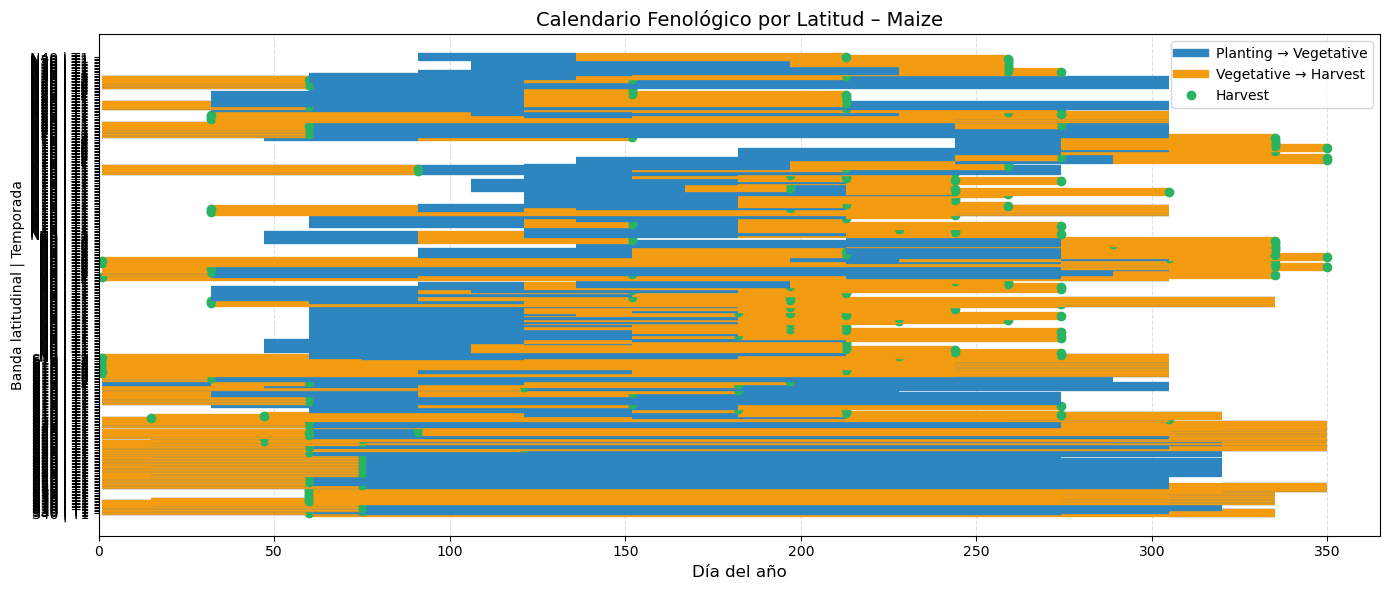

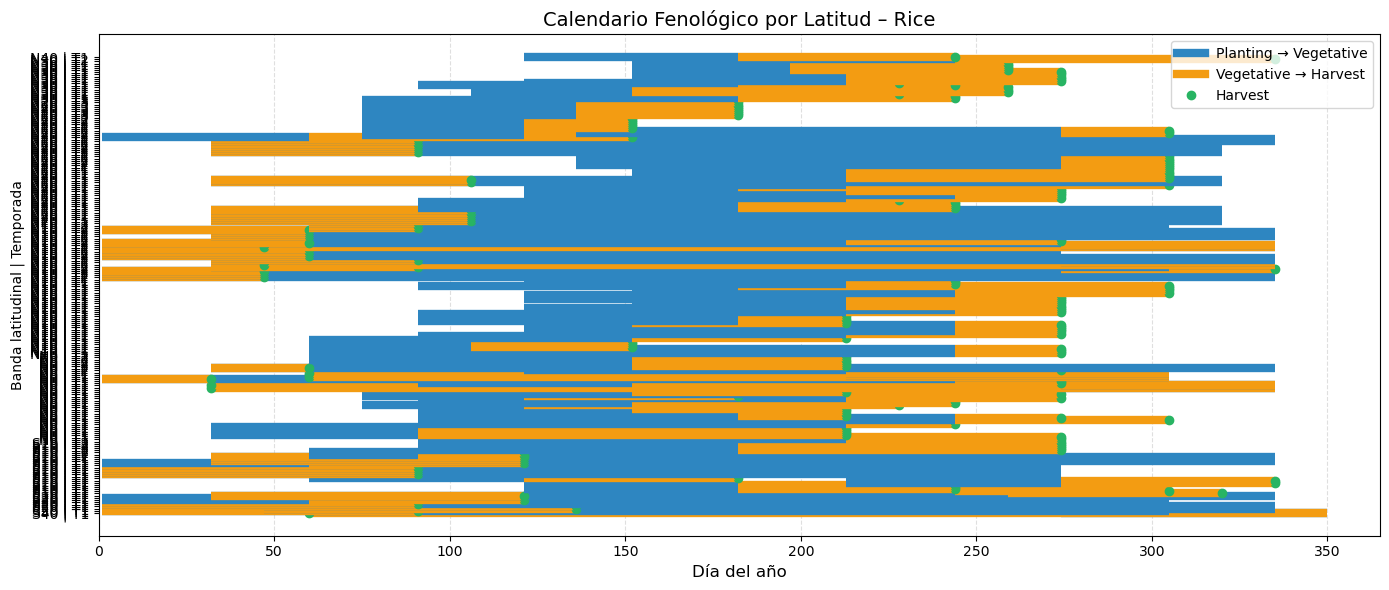

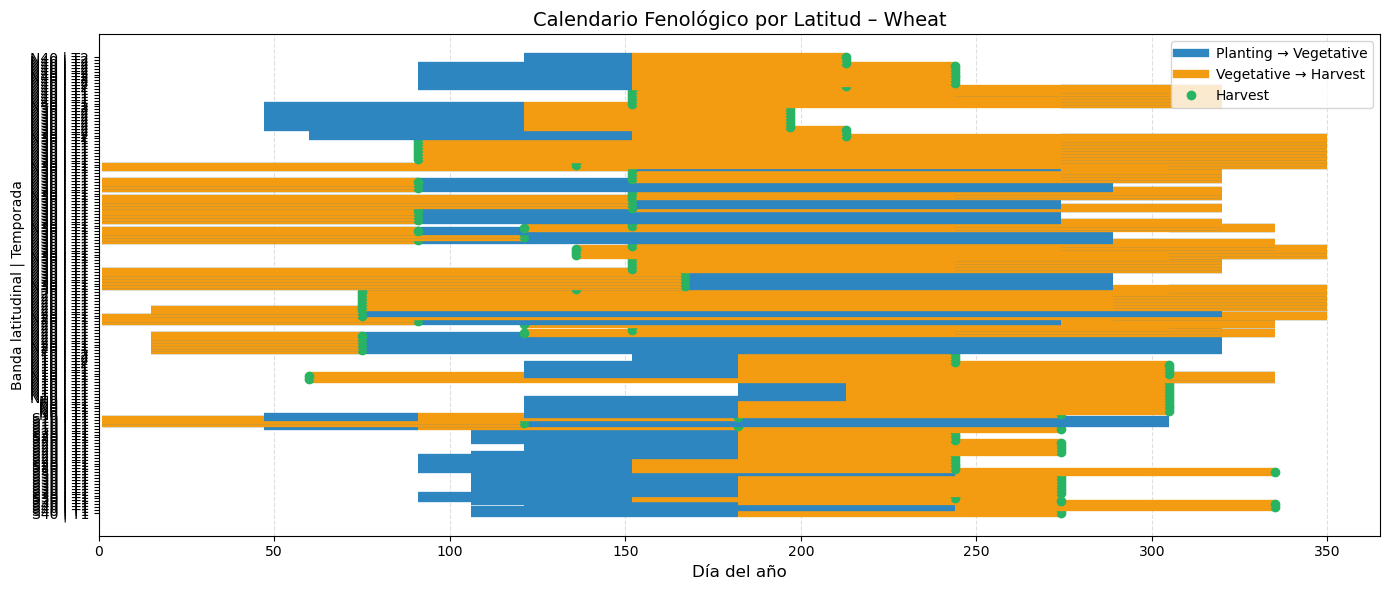

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Cargar archivo limpio
# ============================================================
file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_limpio.xlsx"
df = pd.read_excel(file)

# ============================================================
# 2. Ordenar bandas latitudinales
# ============================================================
orden_lat = ["S40", "S30", "S20", "S10", "N0", "N10", "N20", "N30", "N40"]
df["lat_band"] = pd.Categorical(df["lat_band"], categories=orden_lat, ordered=True)

# Ordenar temporadas
df["temporada_clean"] = df["temporada_clean"].astype(int)
df = df.sort_values(["cultivo", "lat_band", "temporada_clean"])

# ============================================================
# 3. Crear gráfico por cultivo
# ============================================================
cultivos = df["cultivo"].unique()
colores = {"planting":"#2E86C1", "vegetative":"#F39C12", "harvest":"#28B463"}

for cul in cultivos:
    df_c = df[df["cultivo"] == cul].copy()

    # Crear etiquetas del eje Y (convertir Categorical → string)
    df_c["label"] = df_c["lat_band"].astype(str) + " | T" + df_c["temporada_clean"].astype(str)

    # Posiciones numéricas para el timeline
    y_positions = np.arange(len(df_c))
    df_c["y_pos"] = y_positions

    plt.figure(figsize=(14,6))
    plt.title(f"Calendario Fenológico por Latitud – {cul.capitalize()}", fontsize=14)

    for _, row in df_c.iterrows():

        # Planting → Vegetative
        plt.hlines(row["y_pos"], row["planting"], row["vegetative"],
                   colors=colores["planting"], linewidth=6)

        # Vegetative → Harvest
        plt.hlines(row["y_pos"], row["vegetative"], row["harvest"],
                   colors=colores["vegetative"], linewidth=6)

        # Harvest point
        plt.plot(row["harvest"], row["y_pos"], marker="o",
                 color=colores["harvest"], markersize=6)

    # Ajustes de ejes
    plt.yticks(y_positions, df_c["label"])
    plt.xlabel("Día del año", fontsize=12)
    plt.ylabel("Banda latitudinal | Temporada")
    plt.xlim(0, 365)
    plt.grid(axis="x", linestyle="--", alpha=0.4)

    # Leyenda
    handles = [
        plt.Line2D([0],[0], color=colores["planting"], lw=6, label="Planting → Vegetative"),
        plt.Line2D([0],[0], color=colores["vegetative"], lw=6, label="Vegetative → Harvest"),
        plt.Line2D([0],[0], marker="o", color=colores["harvest"], linestyle="", markersize=6, label="Harvest")
    ]
    plt.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    plt.show()


C:\Users\paola\AppData\Local\Temp\ipykernel_30512\2263078087.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_group = df.groupby(


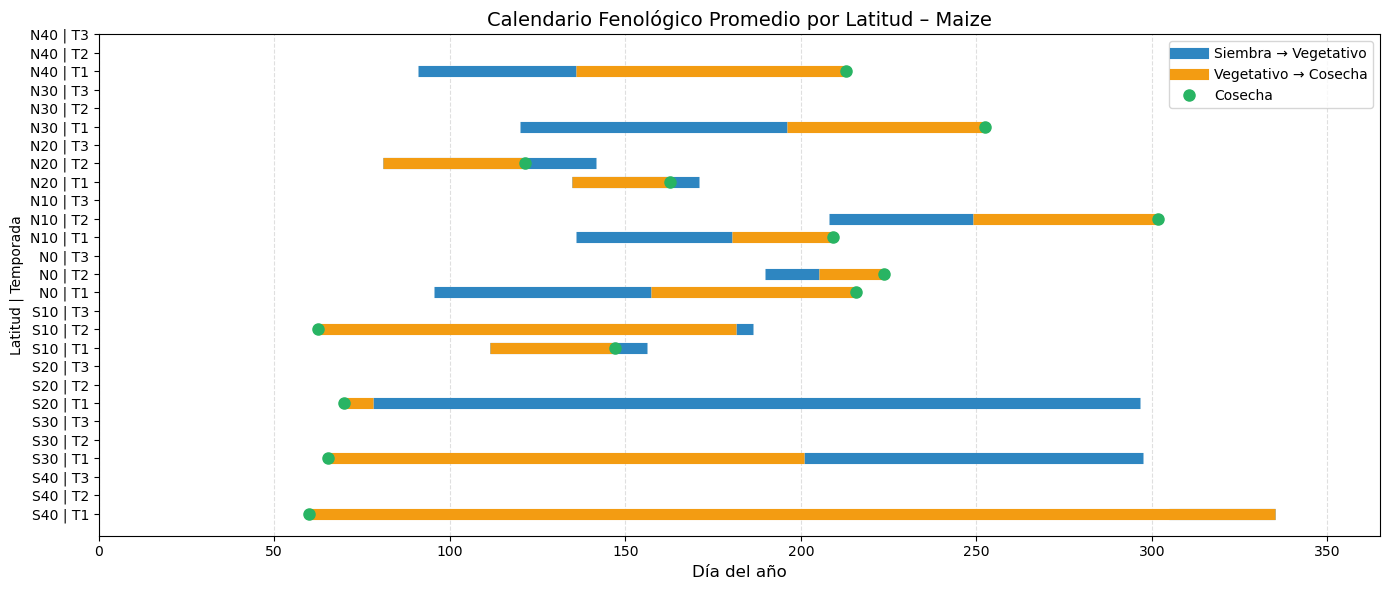

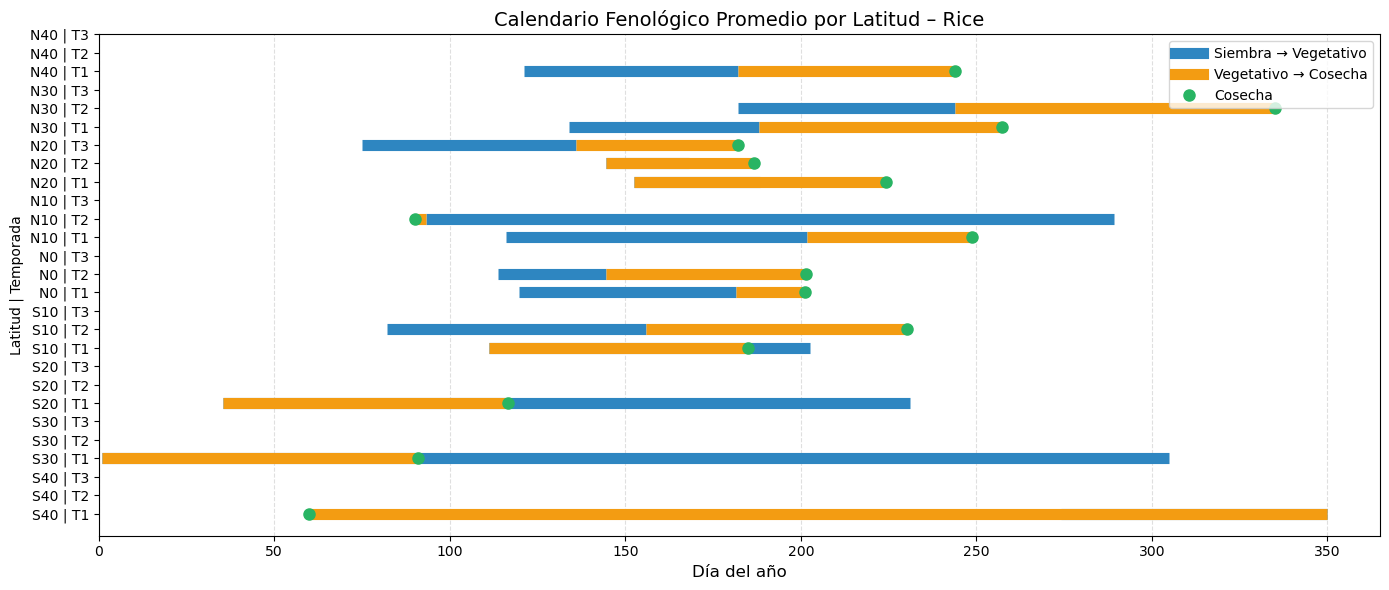

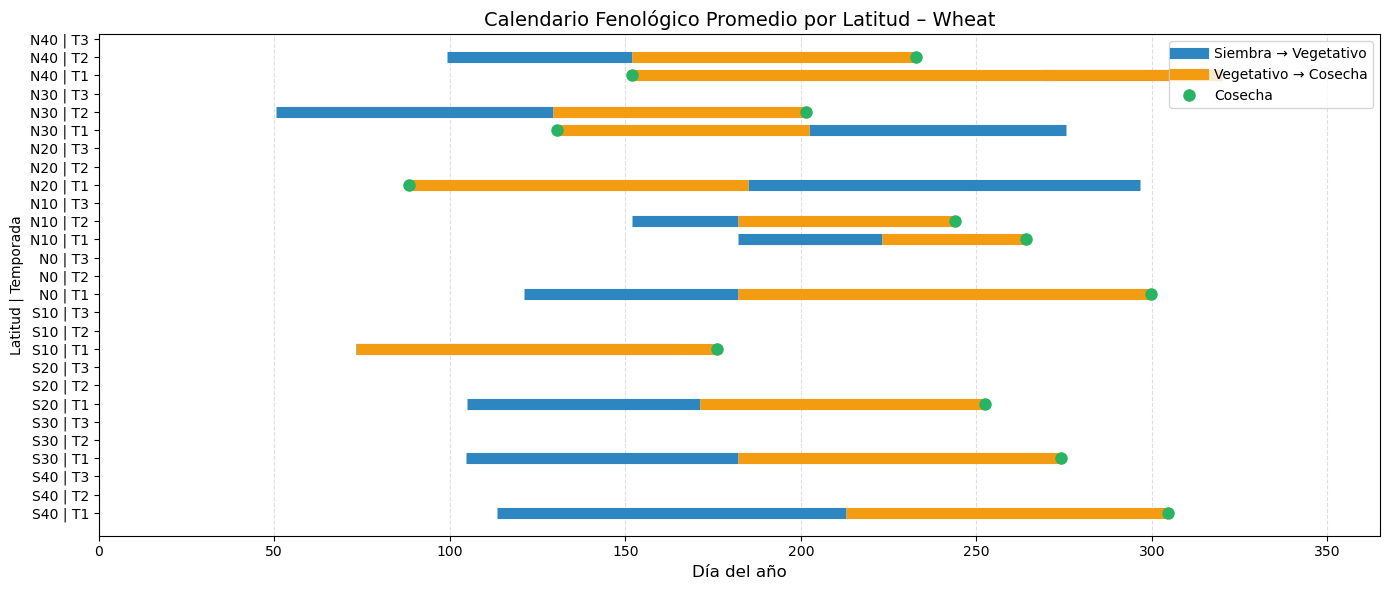

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Cargar archivo limpio
# ============================================================
file = r"C:\Users\paola\Tesis\03_Resultados\Fenologia\Calendario_GEOGLAM_limpio.xlsx"
df = pd.read_excel(file)

# ============================================================
# 2. Ordenar bandas latitudinales
# ============================================================
orden_lat = ["S40", "S30", "S20", "S10", "N0", "N10", "N20", "N30", "N40"]
df["lat_band"] = pd.Categorical(df["lat_band"], categories=orden_lat, ordered=True)

# ============================================================
# 3. AGRUPAR POR CULTIVO + LAT_BAND + TEMPORADA
# ============================================================
df_group = df.groupby(
    ["cultivo", "lat_band", "temporada_clean"],
    as_index=False
)[["planting", "vegetative", "harvest", "dur_veg", "dur_rep", "dur_total"]].mean()

# Crear etiqueta que irá en el eje Y
df_group["label"] = df_group["lat_band"].astype(str) + " | T" + df_group["temporada_clean"].astype(str)

# ============================================================
# 4. GRAFICAR POR CULTIVO
# ============================================================
cultivos = df_group["cultivo"].unique()
colores = {"planting":"#2E86C1", "vegetative":"#F39C12", "harvest":"#28B463"}

for cul in cultivos:
    df_c = df_group[df_group["cultivo"] == cul].copy()

    # Posiciones numéricas para el gráfico
    df_c = df_c.sort_values(["lat_band", "temporada_clean"])
    y_positions = np.arange(len(df_c))
    df_c["y_pos"] = y_positions

    plt.figure(figsize=(14,6))
    plt.title(f"Calendario Fenológico Promedio por Latitud – {cul.capitalize()}", fontsize=14)

    for _, row in df_c.iterrows():

        # Línea fase vegetativa
        plt.hlines(row["y_pos"], row["planting"], row["vegetative"],
                   colors=colores["planting"], linewidth=8)

        # Línea fase reproductiva + maduración
        plt.hlines(row["y_pos"], row["vegetative"], row["harvest"],
                   colors=colores["vegetative"], linewidth=8)

        # Punto de cosecha
        plt.plot(row["harvest"], row["y_pos"], marker="o",
                 color=colores["harvest"], markersize=8)

    plt.yticks(y_positions, df_c["label"])
    plt.xlabel("Día del año", fontsize=12)
    plt.ylabel("Latitud | Temporada")
    plt.xlim(0, 365)
    plt.grid(axis="x", linestyle="--", alpha=0.4)

    handles = [
        plt.Line2D([0],[0], color=colores["planting"], lw=8, label="Siembra → Vegetativo"),
        plt.Line2D([0],[0], color=colores["vegetative"], lw=8, label="Vegetativo → Cosecha"),
        plt.Line2D([0],[0], marker="o", color=colores["harvest"], linestyle="", markersize=8, label="Cosecha")
    ]
    plt.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    plt.show()


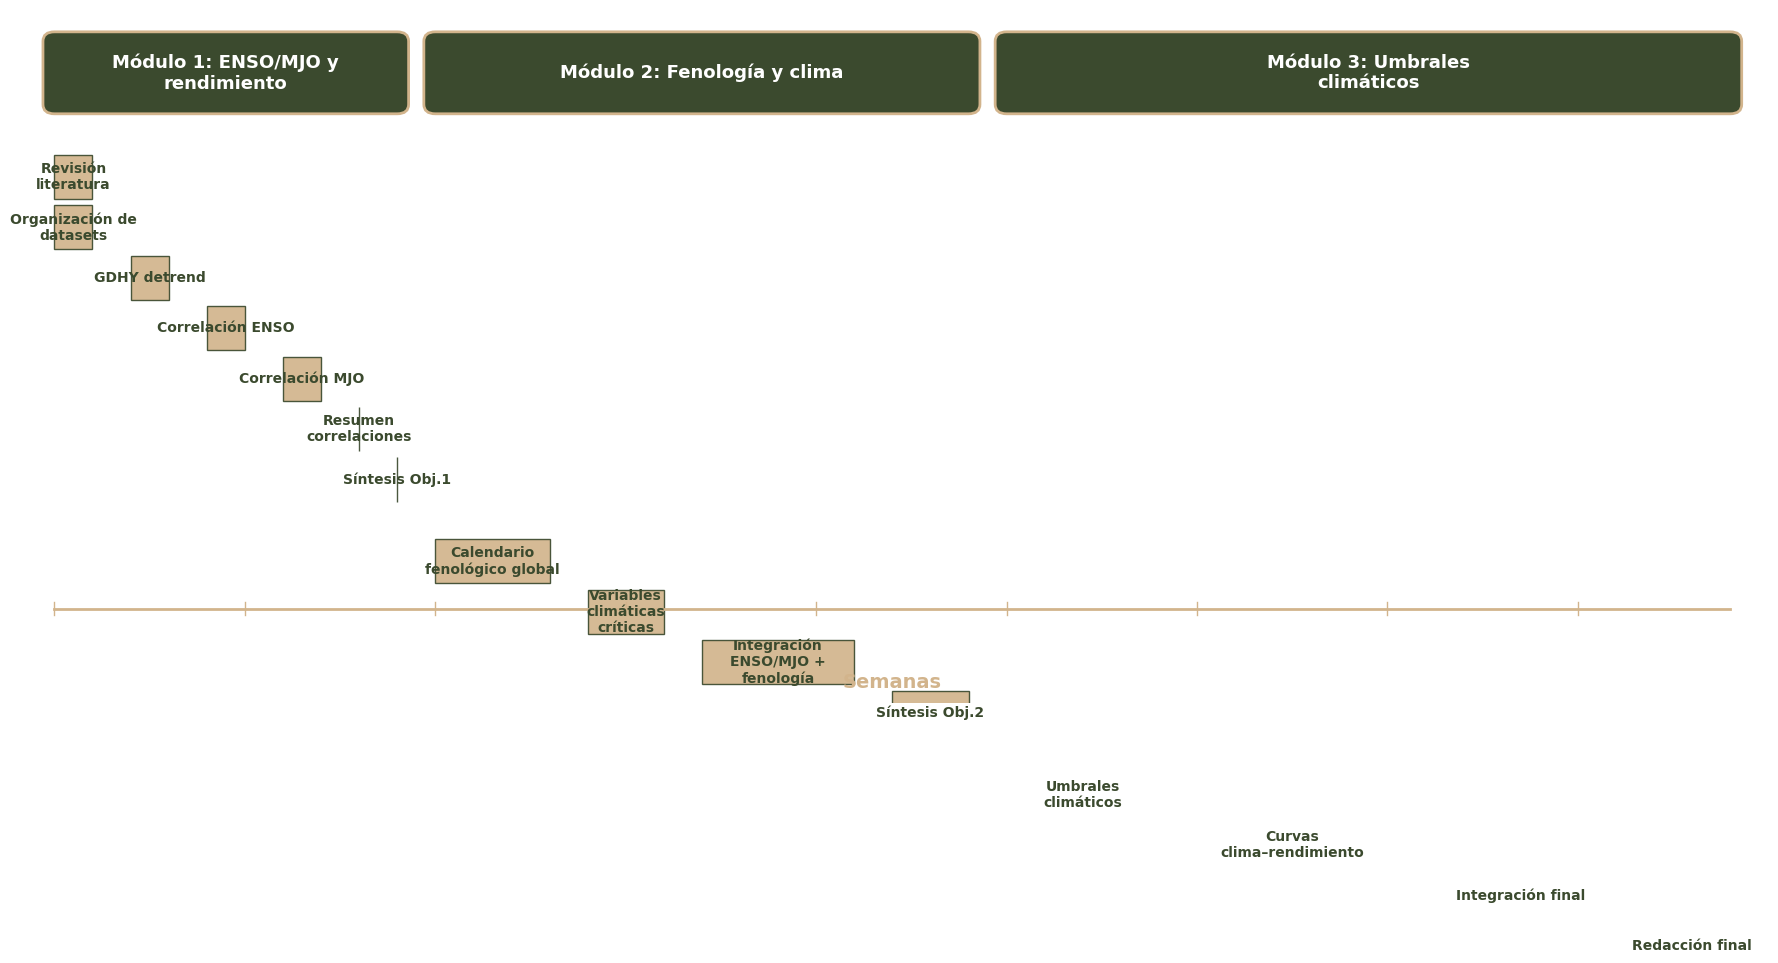

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

# ----------------------------
# DATA (Activities with durations)
# ----------------------------
modules = [
    ("Módulo 1: ENSO/MJO y rendimiento", 1, 10, [
        ("Revisión literatura", 1, 2),
        ("Organización de datasets", 1, 2),
        ("GDHY detrend", 3, 4),
        ("Correlación ENSO", 5, 6),
        ("Correlación MJO", 7, 8),
        ("Resumen correlaciones", 9, 9),
        ("Síntesis Obj.1", 10, 10),
    ]),
    ("Módulo 2: Fenología y clima", 11, 25, [
        ("Calendario fenológico global", 11, 14),
        ("Variables climáticas críticas", 15, 17),
        ("Integración ENSO/MJO + fenología", 18, 22),
        ("Síntesis Obj.2", 23, 25),
    ]),
    ("Módulo 3: Umbrales climáticos", 26, 45, [
        ("Umbrales climáticos", 26, 30),
        ("Curvas clima–rendimiento", 31, 36),
        ("Integración final", 37, 42),
        ("Redacción final", 43, 45),
    ])
]

# Colors
olive = "#3B4A2E"
gold = "#D2B48C"
white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 46)
ax.set_ylim(0, 22)
ax.axis("off")

# ----------------------------
# DRAW MODULE BARS
# ----------------------------
y_pos = 19
for title, start, end, acts in modules:
    ax.add_patch(patches.FancyBboxPatch(
        (start, y_pos), end-start, 2,
        boxstyle="round,pad=0.3",
        edgecolor=gold, facecolor=olive, linewidth=2
    ))
    
    wrapped_title = "\n".join(textwrap.wrap(title, width=28))
    
    ax.text((start+end)/2, y_pos+1, wrapped_title, 
            ha="center", va="center",
            color=white, fontsize=13, weight="bold")

# ----------------------------
# DRAW ACTIVITIES with WRAPPED TEXT
# ----------------------------
y = 16
for _, _, _, acts in modules:
    for act, s, e in acts:
        ax.add_patch(patches.Rectangle(
            (s, y), e-s, 1.4,
            edgecolor=olive, facecolor=gold, alpha=0.92
        ))
        
        wrapped = "\n".join(textwrap.wrap(act, width=18))

        ax.text((s+e)/2, y+0.7, wrapped, 
                ha="center", va="center",
                fontsize=10, color=olive, weight="bold")
        
        y -= 1.6
    y -= 1.0

# ----------------------------
# WEEK AXIS (clean version)
# ----------------------------
ax.plot([1,45],[3,3], color=gold, linewidth=2)

# Tick marks each 5 weeks
tick_positions = list(range(1, 46, 5))
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(t) for t in tick_positions], fontsize=11, color=gold)

# Add axis label
ax.text(23, 0.5, "Semanas", ha="center", fontsize=14, color=gold, weight="bold")

# Draw ticks manually under the line
for t in tick_positions:
    ax.plot([t, t], [2.8, 3.2], color=gold, linewidth=1)

plt.tight_layout()
plt.show()



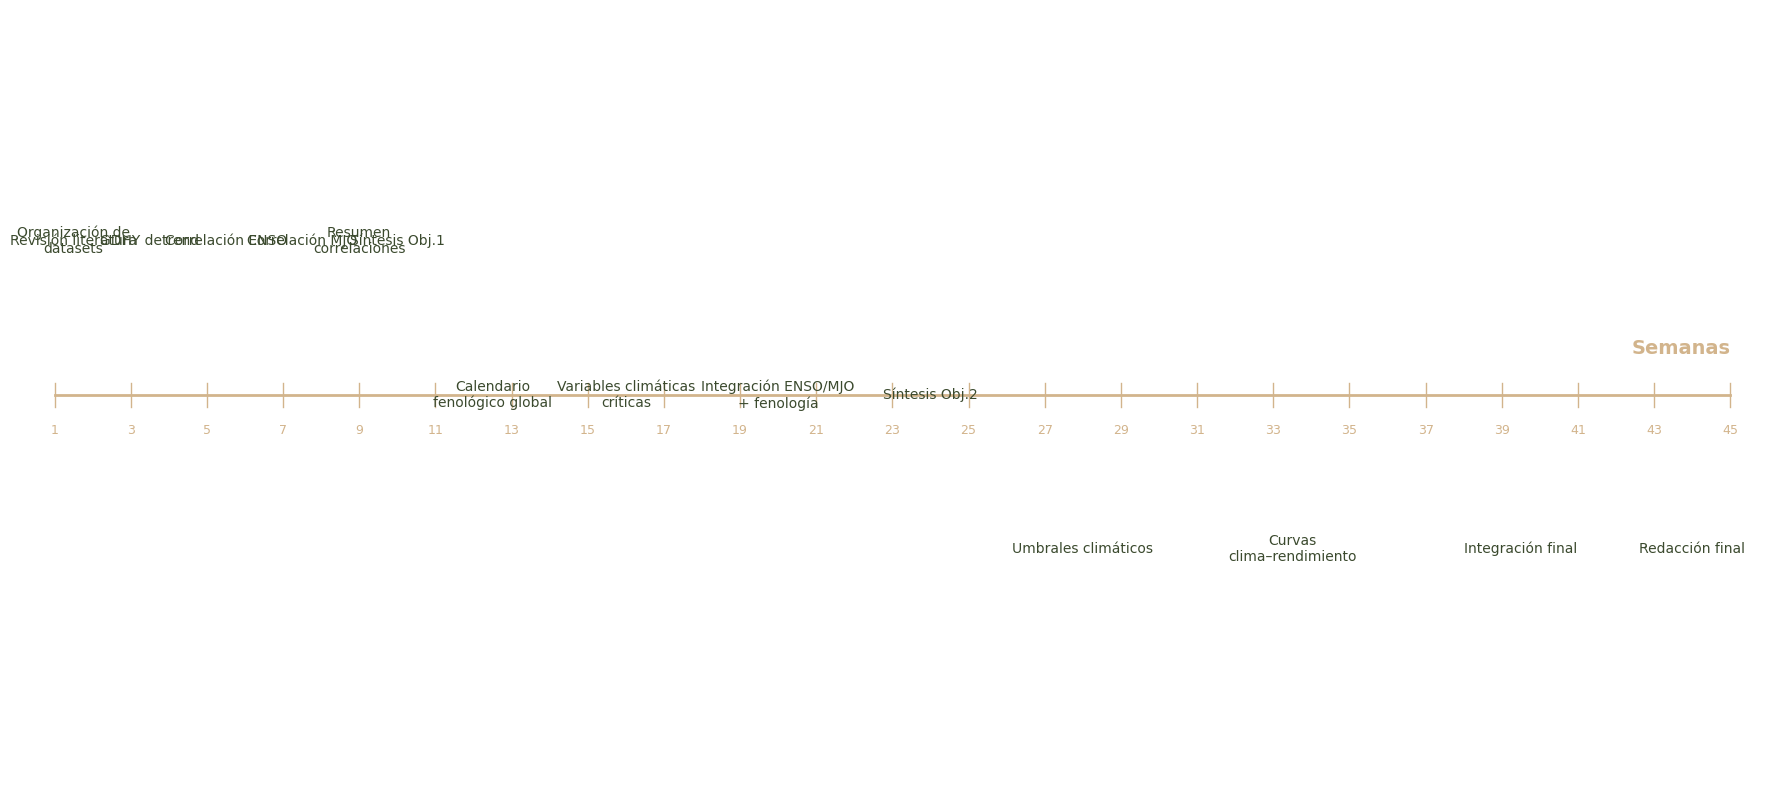

In [13]:
import matplotlib.pyplot as plt
import textwrap

# ----------------------------
# DATA
# ----------------------------
modules = [
    ("Módulo 1", 1, 10, [
        ("Revisión literatura", 1, 2),
        ("Organización de datasets", 1, 2),
        ("GDHY detrend", 3, 4),
        ("Correlación ENSO", 5, 6),
        ("Correlación MJO", 7, 8),
        ("Resumen correlaciones", 9, 9),
        ("Síntesis Obj.1", 10, 10),
    ]),
    
    ("Módulo 2", 11, 25, [
        ("Calendario fenológico global", 11, 14),
        ("Variables climáticas críticas", 15, 17),
        ("Integración ENSO/MJO + fenología", 18, 22),
        ("Síntesis Obj.2", 23, 25),
    ]),
    
    ("Módulo 3", 26, 45, [
        ("Umbrales climáticos", 26, 30),
        ("Curvas clima–rendimiento", 31, 36),
        ("Integración final", 37, 42),
        ("Redacción final", 43, 45),
    ])
]

# Colors
olive = "#3B4A2E"
gold = "#D2B48C"

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 46)
ax.set_ylim(0, 20)
ax.axis("off")

# ----------------------------
# DRAW CENTRAL TIMELINE
# ----------------------------
y_line = 10
ax.plot([1, 45], [y_line, y_line], color=gold, linewidth=2)

# Ticks every 2 weeks
ticks = list(range(1, 46, 2))
for t in ticks:
    ax.plot([t, t], [y_line-0.3, y_line+0.3], color=gold, linewidth=1)
    ax.text(t, y_line-1.0, str(t), ha="center", fontsize=9, color=gold)

# Label "Semanas"
ax.text(45, y_line+1.2, "Semanas", fontsize=14, color=gold,
        ha="right", va="center", weight="bold")

# ----------------------------
# POSITION ACTIVITIES IN THREE BANDS
# ----------------------------
band_levels = {0: 14, 1: 10, 2: 6}  # Three vertical bands
band_index = 0

for _, _, _, acts in modules:
    y_band = band_levels[band_index]
    
    for act, start, end in acts:
        mid = (start + end) / 2
        wrapped = "\n".join(textwrap.wrap(act, width=20))
        ax.text(mid, y_band, wrapped, ha="center", va="center",
                fontsize=10, color=olive)
    
    band_index += 1

plt.tight_layout()
plt.show()


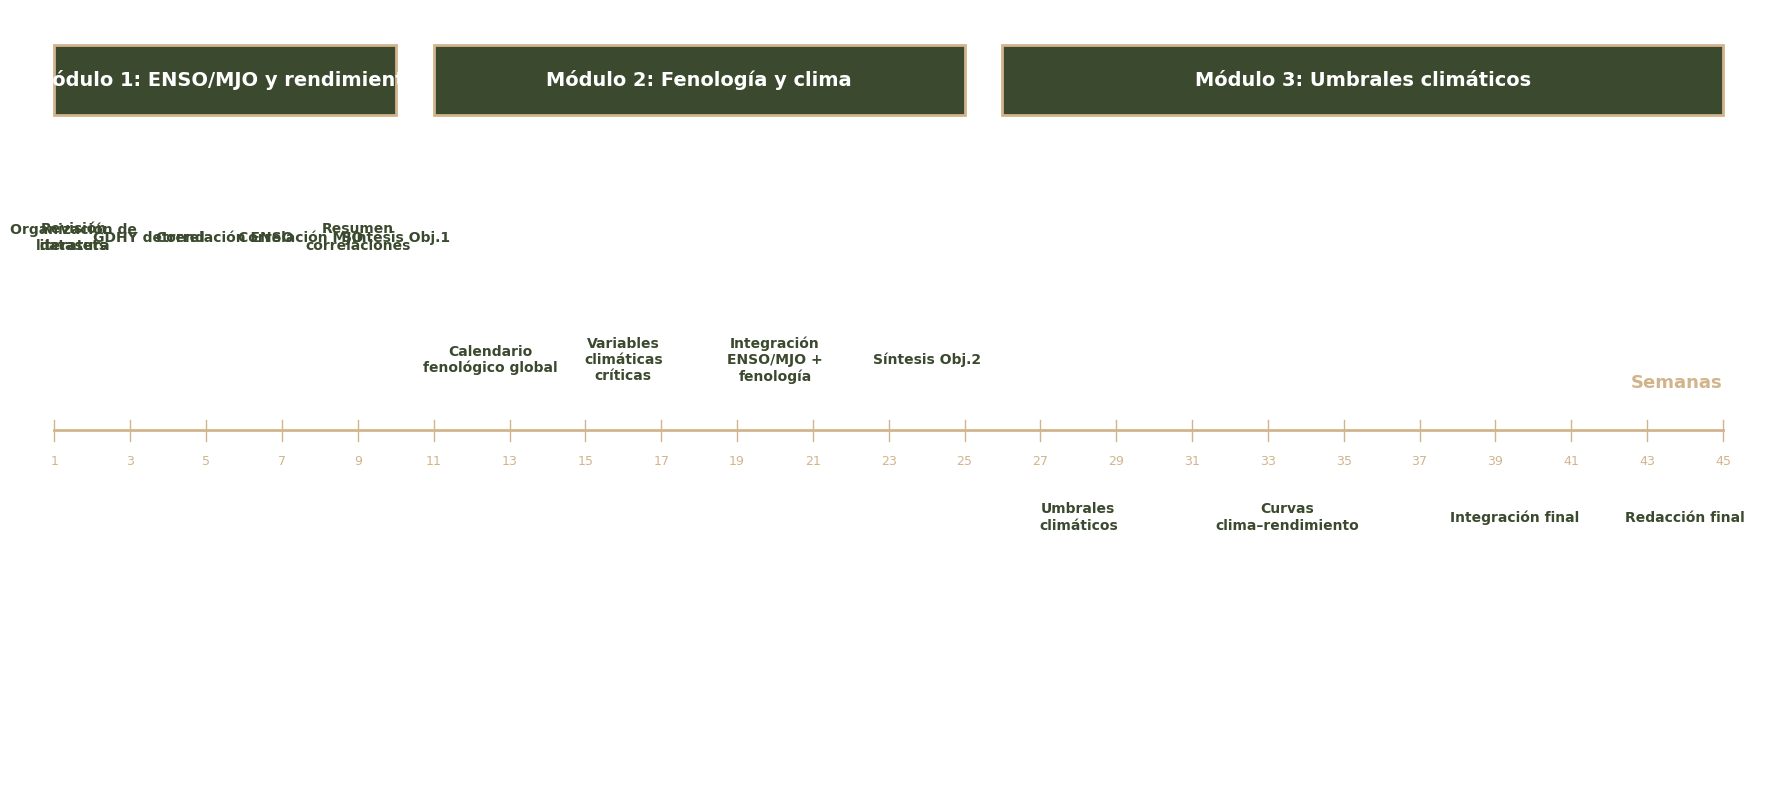

In [14]:
import matplotlib.pyplot as plt
import textwrap

# ----------------------------
# DATA (same tasks and modules)
# ----------------------------
modules = [
    ("Módulo 1: ENSO/MJO y rendimiento", 1, 10, [
        ("Revisión literatura", 1, 2),
        ("Organización de datasets", 1, 2),
        ("GDHY detrend", 3, 4),
        ("Correlación ENSO", 5, 6),
        ("Correlación MJO", 7, 8),
        ("Resumen correlaciones", 9, 9),
        ("Síntesis Obj.1", 10, 10),
    ]),
    
    ("Módulo 2: Fenología y clima", 11, 25, [
        ("Calendario fenológico global", 11, 14),
        ("Variables climáticas críticas", 15, 17),
        ("Integración ENSO/MJO + fenología", 18, 22),
        ("Síntesis Obj.2", 23, 25),
    ]),
    
    ("Módulo 3: Umbrales climáticos", 26, 45, [
        ("Umbrales climáticos", 26, 30),
        ("Curvas clima–rendimiento", 31, 36),
        ("Integración final", 37, 42),
        ("Redacción final", 43, 45),
    ])
]

# Colors
olive = "#3B4A2E"
gold = "#D2B48C"
white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 46)
ax.set_ylim(0, 22)
ax.axis("off")

# ----------------------------
# MODULE HEADERS (match your design)
# ----------------------------
y_header = 19
for title, start, end, _ in modules:
    ax.add_patch(plt.Rectangle(
        (start, y_header), end - start, 2,
        edgecolor=gold, facecolor=olive,
        linewidth=2, zorder=2
    ))
    ax.text((start + end) / 2, y_header + 1, title,
            ha="center", va="center", color=white,
            fontsize=14, weight="bold")

# ----------------------------
# MAIN TIMELINE
# ----------------------------
y_line = 10
ax.plot([1, 45], [y_line, y_line], color=gold, linewidth=2)

# Ticks each 2 weeks
ticks = list(range(1, 46, 2))
for t in ticks:
    ax.plot([t, t], [y_line - 0.3, y_line + 0.3], color=gold, linewidth=1)
    ax.text(t, y_line - 1, str(t),
            ha="center", fontsize=9, color=gold)

# "Semanas" label (right aligned)
ax.text(45, y_line + 1.2, "Semanas", ha="right",
        fontsize=13, color=gold, weight="bold")

# ----------------------------
# ACTIVITIES (TEXT ONLY – floating)
# ----------------------------
bands = {0: 15.5, 1: 12.0, 2: 7.5}  # three vertical bands
band_idx = 0

for _, _, _, acts in modules:
    y_band = bands[band_idx]
    
    for act, start, end in acts:
        mid = (start + end) / 2
        wrapped = "\n".join(textwrap.wrap(act, width=18))
        ax.text(mid, y_band, wrapped,
                ha="center", va="center",
                fontsize=10, color=olive, weight="bold")
    
    band_idx += 1

plt.tight_layout()
plt.show()


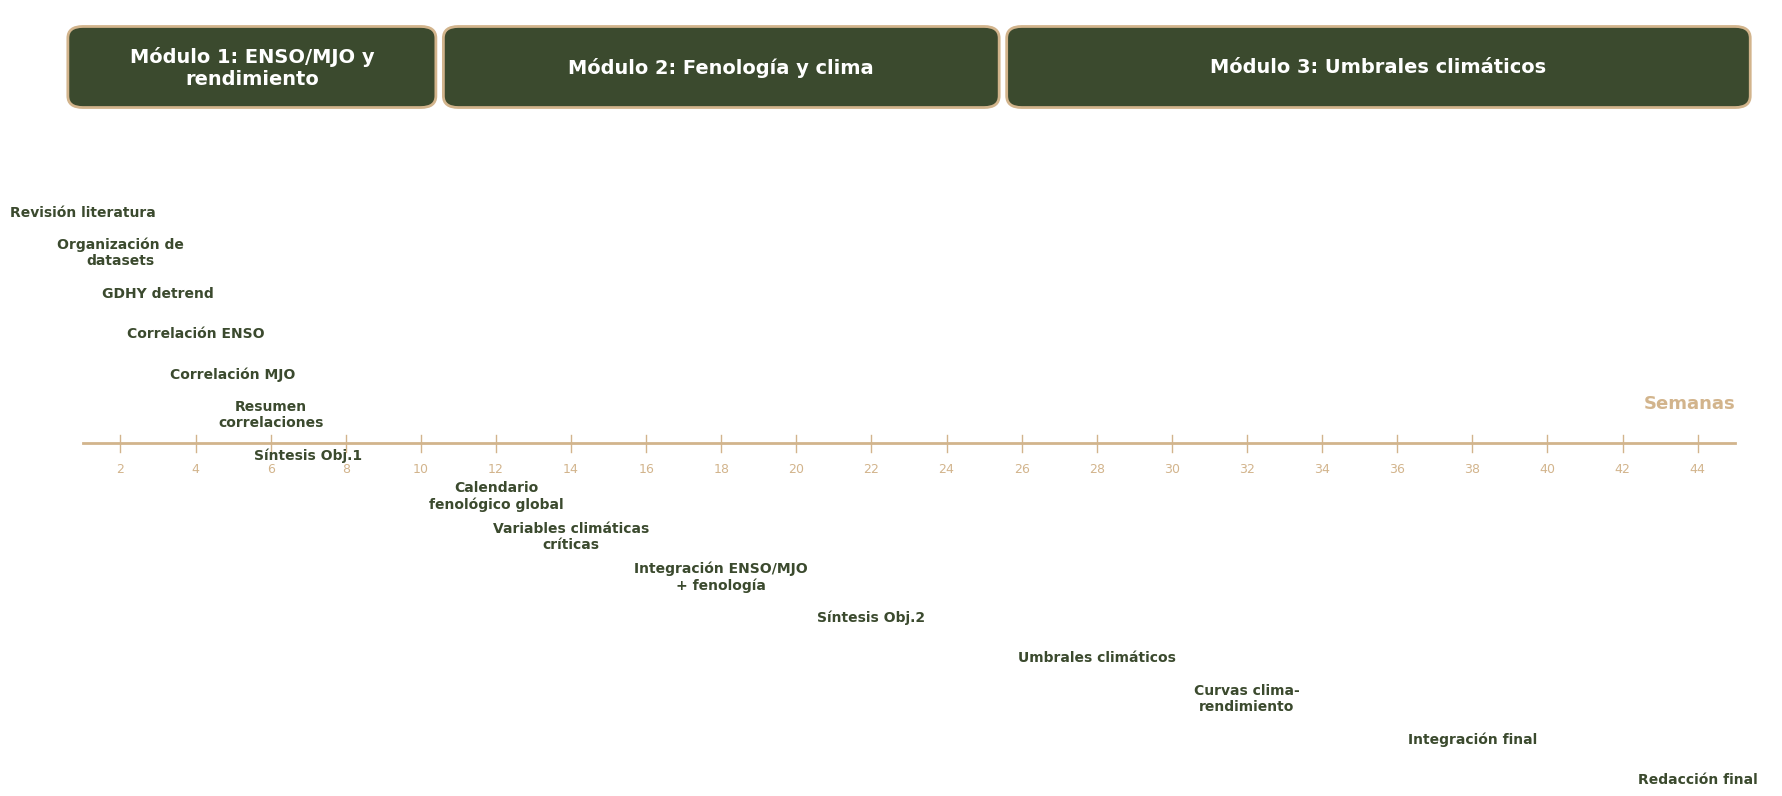

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

# ----------------------------
# DATA
# ----------------------------
activities = [
    ("Revisión literatura", 1),
    ("Organización de datasets", 2),
    ("GDHY detrend", 3),
    ("Correlación ENSO", 4),
    ("Correlación MJO", 5),
    ("Resumen correlaciones", 6),
    ("Síntesis Obj.1", 7),
    
    ("Calendario fenológico global", 12),
    ("Variables climáticas críticas", 14),
    ("Integración ENSO/MJO + fenología", 18),
    ("Síntesis Obj.2", 22),

    ("Umbrales climáticos", 28),
    ("Curvas clima-rendimiento", 32),
    ("Integración final", 38),
    ("Redacción final", 44)
]

modules = [
    ("Módulo 1: ENSO/MJO y rendimiento", 1, 10),
    ("Módulo 2: Fenología y clima", 11, 25),
    ("Módulo 3: Umbrales climáticos", 26, 45)
]

# Colors
olive = "#3B4A2E"
gold = "#D2B48C"
white = "#FFFFFF"

# ----------------------------
# FIGURE
# ----------------------------
fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 46)
ax.set_ylim(0, 25)
ax.axis("off")

# ----------------------------
# MODULE HEADERS (rectangles with text inside)
# ----------------------------
y_mod = 22
for title, start, end in modules:
    ax.add_patch(patches.FancyBboxPatch(
        (start, y_mod), end - start, 2,
        boxstyle="round,pad=0.4",
        edgecolor=gold, facecolor=olive, linewidth=2
    ))

    ax.text(
        (start + end) / 2, y_mod + 1,
        "\n".join(textwrap.wrap(title, width=30)),
        ha="center", va="center",
        fontsize=14, color=white, weight="bold"
    )

# ----------------------------
# CENTRAL TIMELINE
# ----------------------------
y_line = 10
ax.plot([1, 45], [y_line, y_line], color=gold, linewidth=2)

# ticks every 2 weeks
for wk in range(2, 46, 2):
    ax.plot([wk, wk], [y_line - 0.3, y_line + 0.3], color=gold, linewidth=1)
    ax.text(wk, y_line - 1, str(wk), ha="center", fontsize=9, color=gold)

# "Semanas"
ax.text(45, y_line + 1.2, "Semanas",
        ha="right", fontsize=13, color=gold, weight="bold")

# ----------------------------
# CASCADA DE ACTIVIDADES
# ----------------------------
y_start = 18      # altura inicial
y_step = -1.4     # caída en cascada

for i, (label, week) in enumerate(activities):
    y = y_start + i * y_step
    ax.text(
        week, y,
        "\n".join(textwrap.wrap(label, width=20)),
        ha="center", va="center",
        fontsize=10, color=olive, weight="bold"
    )

plt.tight_layout()
plt.show()


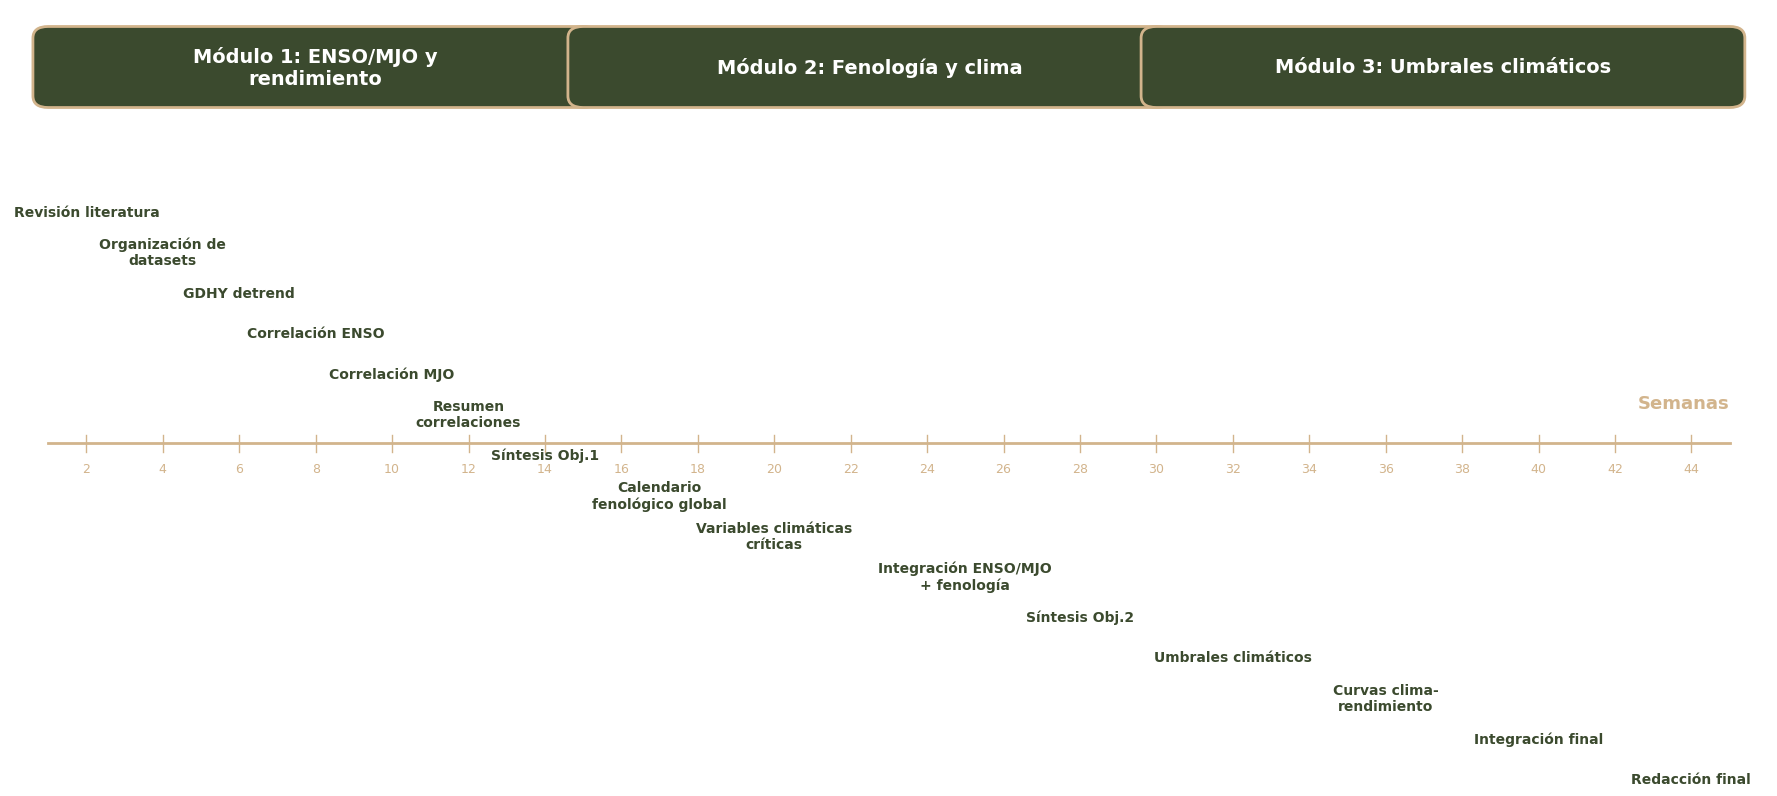

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

# -----------------------------------
# NEW DISTRIBUTION (balanced modules)
# -----------------------------------

activities = [
    # MÓDULO 1 (1–15)
    ("Revisión literatura", 2),
    ("Organización de datasets", 4),
    ("GDHY detrend", 6),
    ("Correlación ENSO", 8),
    ("Correlación MJO", 10),
    ("Resumen correlaciones", 12),
    ("Síntesis Obj.1", 14),

    # MÓDULO 2 (15–30)
    ("Calendario fenológico global", 17),
    ("Variables climáticas críticas", 20),
    ("Integración ENSO/MJO + fenología", 25),
    ("Síntesis Obj.2", 28),

    # MÓDULO 3 (30–45)
    ("Umbrales climáticos", 32),
    ("Curvas clima-rendimiento", 36),
    ("Integración final", 40),
    ("Redacción final", 44)
]

modules = [
    ("Módulo 1: ENSO/MJO y rendimiento", 1, 15),
    ("Módulo 2: Fenología y clima", 15, 30),
    ("Módulo 3: Umbrales climáticos", 30, 45)
]

# Colors
olive = "#3B4A2E"
gold = "#D2B48C"
white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 46)
ax.set_ylim(0, 25)
ax.axis("off")

# -----------------------------------
# MODULE HEADERS
# -----------------------------------
y_mod = 22
for title, start, end in modules:
    ax.add_patch(patches.FancyBboxPatch(
        (start, y_mod), end - start, 2,
        boxstyle="round,pad=0.4",
        edgecolor=gold, facecolor=olive, linewidth=2
    ))

    ax.text((start + end) / 2, y_mod + 1,
            "\n".join(textwrap.wrap(title, width=30)),
            ha="center", va="center",
            fontsize=14, color=white, weight="bold")

# -----------------------------------
# TIMELINE with ticks every 2 weeks
# -----------------------------------
y_line = 10
ax.plot([1, 45], [y_line, y_line], color=gold, linewidth=2)

for wk in range(2, 46, 2):
    ax.plot([wk, wk], [y_line - 0.3, y_line + 0.3], color=gold, linewidth=1)
    ax.text(wk, y_line - 1, str(wk),
            ha="center", fontsize=9, color=gold)

ax.text(45, y_line + 1.2, "Semanas",
        ha="right", fontsize=13, color=gold, weight="bold")

# -----------------------------------
# CASCADA DE ACTIVIDADES equidistante
# -----------------------------------
y_start = 18
y_step = -1.4

for i, (label, week) in enumerate(activities):
    y = y_start + i * y_step
    wrapped = "\n".join(textwrap.wrap(label, width=20))

    ax.text(
        week, y,
        wrapped,
        ha="center", va="center",
        fontsize=10, color=olive, weight="bold"
    )

plt.tight_layout()
plt.show()


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

# Colores
olive = "#3B4A2E"
gold = "#D2B48C"
white = "#FFFFFF"

# Definir cajas (x, y, width, height, texto)
boxes = [
    (0.2, 0.75, 0.6, 0.15,
     "1. Teleconexiones ENSO–MJO\nCorrelaciones globales y sensibilidad climática"),
    (0.2, 0.45, 0.6, 0.15,
     "2. Fenología agrícola\nVentanas críticas por cultivo y fase"),
    (0.2, 0.15, 0.6, 0.15,
     "3. Umbrales climáticos\nCurvas clima–rendimiento y síntesis final")
]

# Dibujar cajas
for x, y, w, h, text in boxes:
    ax.add_patch(patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.3",
        edgecolor=gold, facecolor=olive, linewidth=2
    ))
    ax.text(x + w/2, y + h/2, text,


SyntaxError: incomplete input (2118589056.py, line 29)